<a href="https://colab.research.google.com/github/Ariely13/Tugas/blob/main/Tugas_Praktikum_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df = pd.read_csv(r"https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/1D_Porosity.csv") # data from Dr. Pyrcz's github repository

In [ ]:
# Reshape data untuk Scikit-Learn
X = df[['Depth']]
y = df['Nporosity']

In [ ]:
# Membuat dan melatih model Linear Sederhana
model_lin = LinearRegression()
model_lin.fit(X, y)
y_pred_lin = model_lin.predict(X)

In [ ]:
# Menghitung Metrik Error
mae = mean_absolute_error(y, y_pred_lin)
mse = mean_squared_error(y, y_pred_lin)
rmse = np.sqrt(mse)

In [ ]:
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 0.7399
MSE  : 0.7979
RMSE : 0.8933


MAE (0.7399): Secara rata-rata, prediksi model meleset sebesar 0.73 unit dari data asli.

MSE (0.7979): Rata-rata kuadrat kesalahan; nilai ini menonjolkan pengaruh error yang besar (outlier).

RMSE (0.8933): Standar deviasi dari error; menunjukkan bahwa sebagian besar data menyimpang sekitar 0.89 unit dari garis regresi.

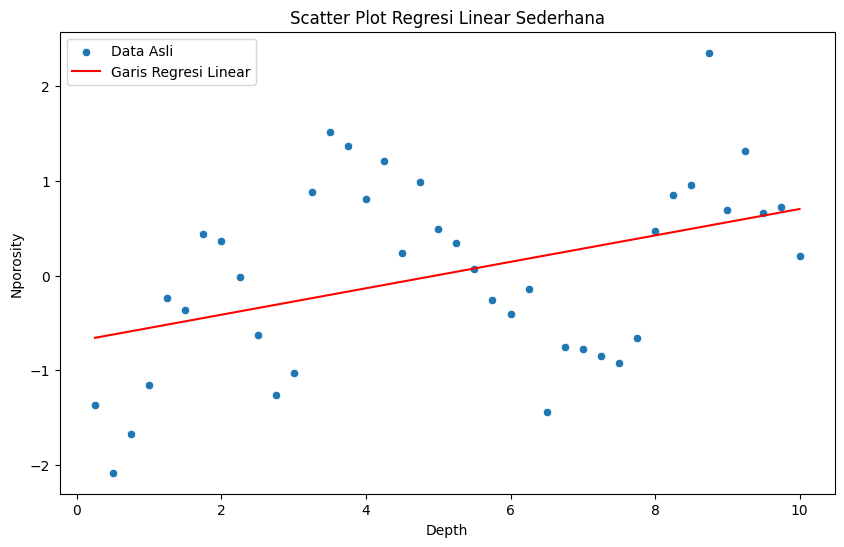

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=df, label='Data Asli')
plt.plot(df['Depth'], y_pred_lin, color='red', label='Garis Regresi Linear')
plt.title('Scatter Plot Regresi Linear Sederhana')
plt.legend()
plt.show()

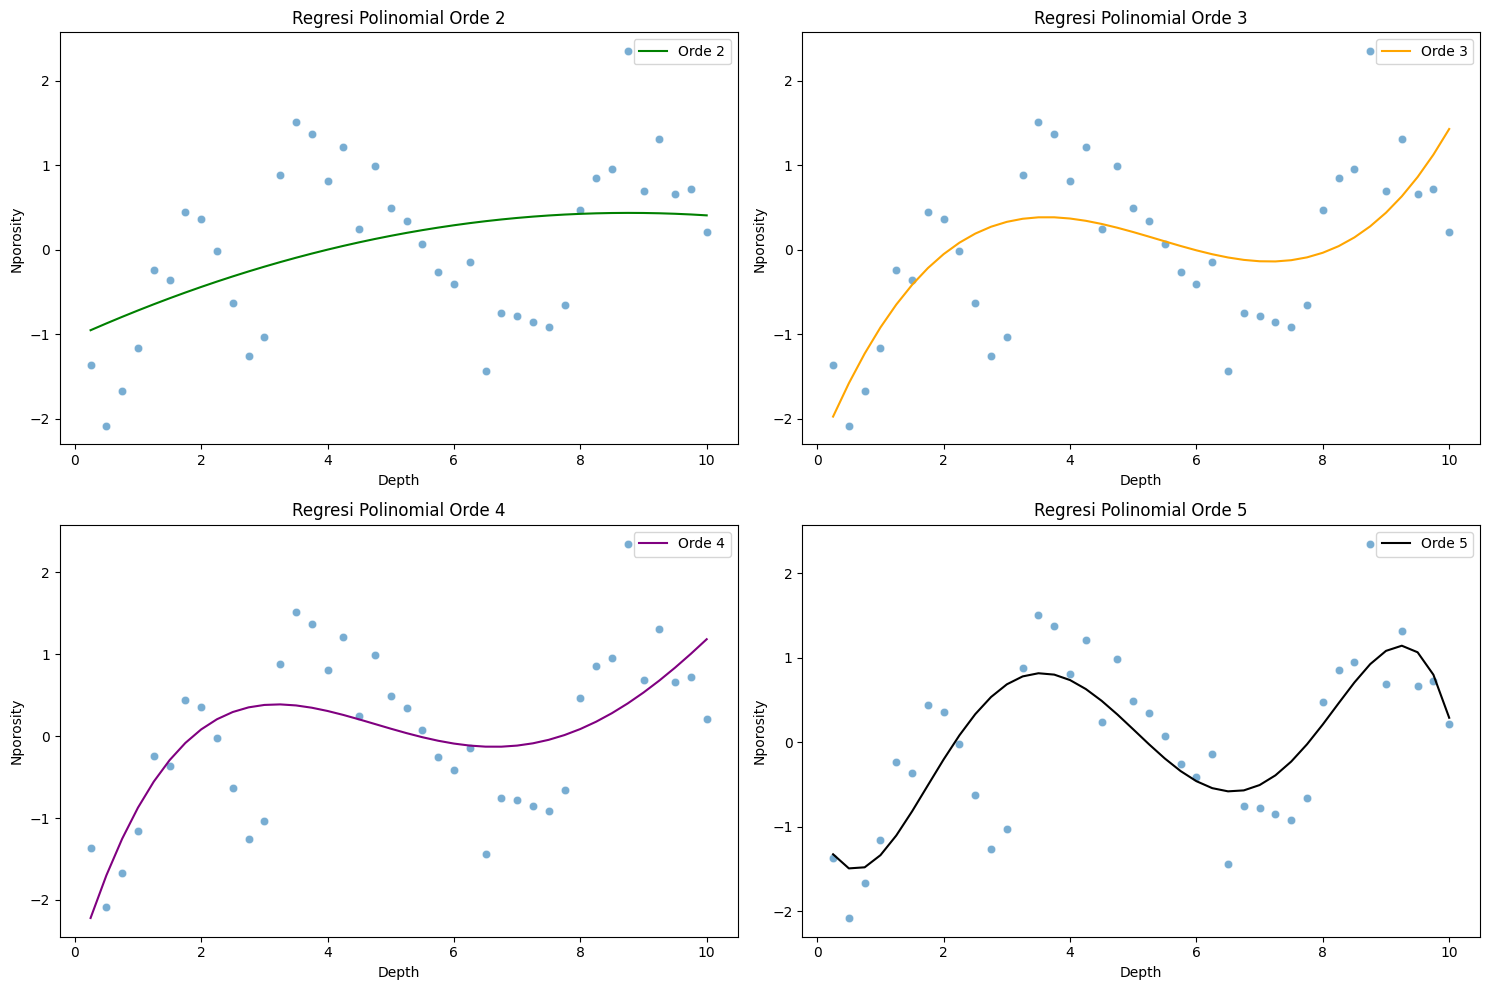

In [ ]:
orders = [2, 3, 4, 5]
colors = ['green', 'orange', 'purple', 'black']

plt.figure(figsize=(15, 10))

for i, order in enumerate(orders):
    # Transformasi data ke Polynomial
    poly_features = PolynomialFeatures(degree=order)
    X_poly = poly_features.fit_transform(X)

    # Training model
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)
    y_poly_pred = poly_model.predict(X_poly)

    # Plotting
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x='Depth', y='Nporosity', data=df, alpha=0.6)
    plt.plot(df['Depth'], y_poly_pred, color=colors[i], label=f'Orde {order}')
    plt.title(f'Regresi Polinomial Orde {order}')
    plt.legend()

plt.tight_layout()
plt.show()

1.Regresi Polinomial Orde 2

Kurva berbentuk parabola.Menunjukkan bahwa porosity meningkat seiring bertambahnya depth sampai titik tertentu, kemudian cenderung stabil atau sedikit menurun.Model ini masih cukup sederhana dan belum mengikuti semua pola data.

2.Regresi Polinomial Orde 3

Kurva mulai lebih fleksibel.Terlihat ada kenaikan → penurunan → kenaikan kembali pada nilai porosity.Artinya hubungan depth dan porosity tidak linear dan memiliki beberapa perubahan pola.
Regresi Polinomial Orde 4

3.Kurva lebih halus dan mengikuti distribusi titik data lebih baik.

Menunjukkan bahwa porosity meningkat pada kedalaman awal, menurun di tengah, lalu meningkat kembali pada kedalaman besar.Model ini biasanya lebih representatif dibanding orde 2 dan 3.

4.Regresi Polinomial Orde 5

Kurva sangat fleksibel dan mengikuti banyak titik data.Namun mulai terlihat gelombang yang terlalu banyak.Hal ini menunjukkan kemungkinan overfitting, yaitu model terlalu mengikuti data sampel sehingga kurang baik untuk prediksi data baru.